This will take in lists of possible features and then print the outputs

In [20]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [21]:
%matplotlib inline

import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss

In [22]:
class simple_net(nn.Module):
    def __init__(self,input_size, hidden_size=10, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [23]:
# This is received from the ff with a single item/store
spec_1 = [
    '6_day_lag', 
    '180_day_rolling_mean', 
    '90_day_rolling_volatility', 
    '90_day_rolling_ema', 
    'diff_30_day', 
    '7_day_rolling_mean', 
    '3_day_lag', 
    'circular_sin_cos_day_of_week', 
    '180_day_rolling_min', 
    'diff_365_day', 
    'one_hot_month', 
    '30_day_rolling_mean', 
    'circular_sin_cos_week', 
    '5_day_lag', 
    '180_day_rolling_ema']

# This is gotten from feature selection
spec_2 = [
    "7_day_rolling_ema",	
    "7_day_rolling_mean",	
    "30_day_rolling_ema",	
    "diff_180_day",	
    "diff_90_day",	
    "30_day_rolling_mean",	
    "diff_30_day",	
    "7_day_rolling_min",	
    "7_day_lag",	
    "30_day_rolling_min",	
    "14_day_lag",	
    "diff_365_day",	
]

In [24]:
all_specs = [spec_1, spec_2]

num_epochs = 500

Evaluating spec 1 with 15 features
Evaluating spec 2 with 12 features


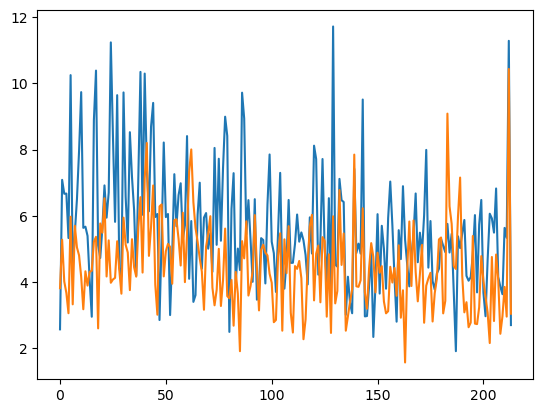

In [ ]:
perfomances = [[[], [], []] for _ in range(len(all_specs))]

h_cost = 1
l_cost = 3

for i, spec in enumerate(all_specs):
    print(f"Evaluating spec {i+1} with {len(spec)} features")

    # First combine the items
    train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[
        ("item", 1)
    ],
    specs=spec,
    combine_items=True
    )

    net = simple_net(train_loader.dataset.x.shape[1], hidden_size=train_loader.dataset.x.shape[1], output_size=train_loader.dataset.y.shape[1])
    loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    _, _ = train(net, optimizer, loss, train_loader, val_loader, epochs=num_epochs, device="cpu", use_tqdm=False, eval_interval=None)
    test_loss = get_test_loss(net, test_loader, loss, "cpu")
    perfomances[i][0].append(test_loss)

    # Then combine the stores
    train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[
        ("store", 1)
    ],
    specs=spec,
    combine_stores=True
    )

    net = simple_net(train_loader.dataset.x.shape[1], hidden_size=train_loader.dataset.x.shape[1], output_size=train_loader.dataset.y.shape[1])
    loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    _, _ = train(net, optimizer, loss, train_loader, val_loader, epochs=num_epochs, device="cpu", use_tqdm=False, eval_interval=None)
    test_loss = get_test_loss(net, test_loader, loss, "cpu")
    perfomances[i][1].append(test_loss)

    # Then combine the items and stores
    # First combine the items
    train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=spec,
    combine_items=True,
    combine_stores=True
    )

    net = simple_net(train_loader.dataset.x.shape[1], hidden_size=train_loader.dataset.x.shape[1], output_size=train_loader.dataset.y.shape[1])
    loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    _, _ = train(net, optimizer, loss, train_loader, val_loader, epochs=num_epochs, device="cpu", use_tqdm=False, eval_interval=None)
    test_loss = get_test_loss(net, test_loader, loss, "cpu")
    perfomances[i][2].append(test_loss)

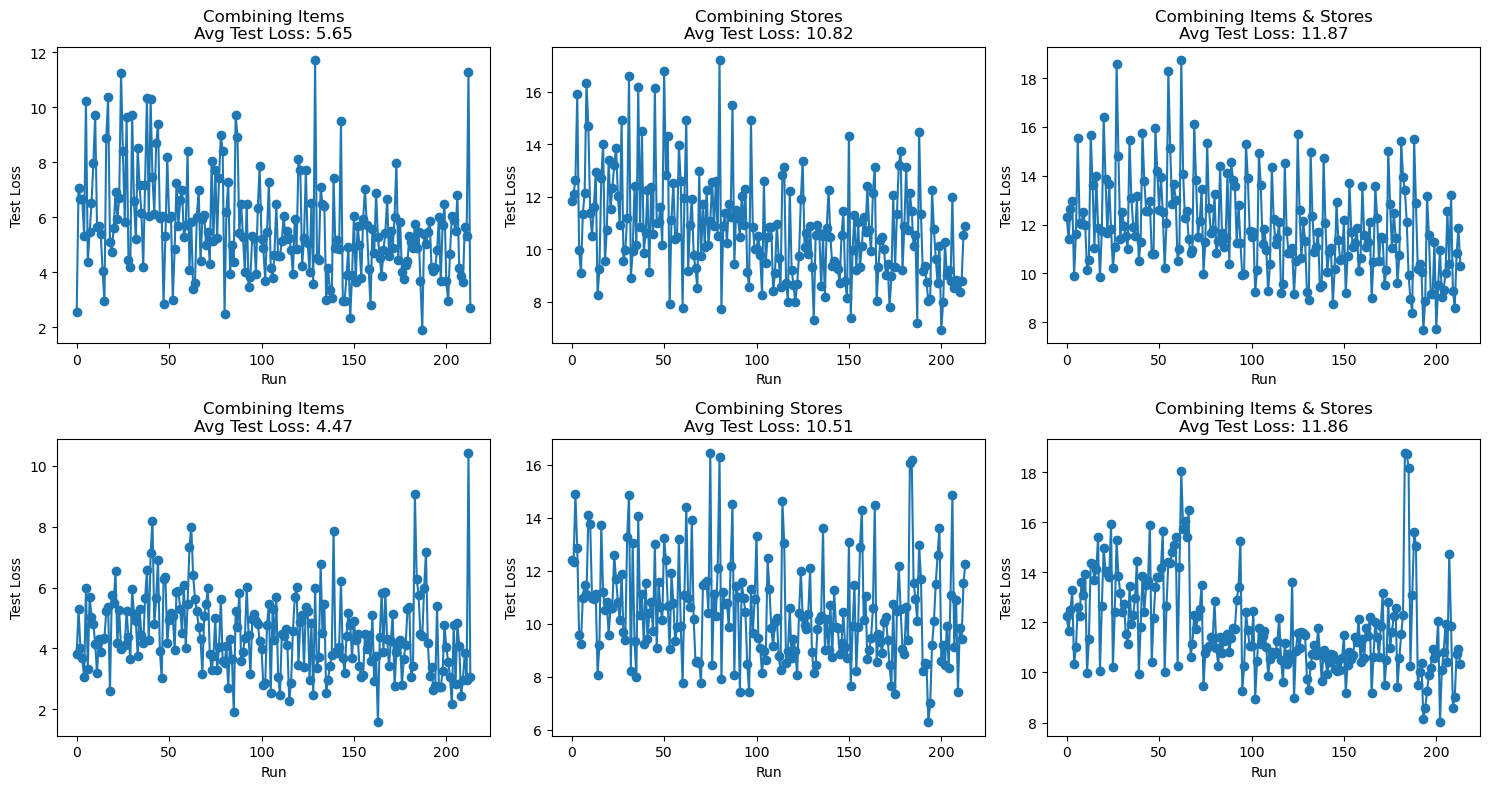

In [26]:
import numpy as np

num_specs = len(perfomances)
fig, axes = plt.subplots(num_specs, 3, figsize=(15, 4 * num_specs), squeeze=False)

titles = [
    "Combining Items",
    "Combining Stores",
    "Combining Items & Stores"
]

for i in range(num_specs):
    for j in range(3):
        ax = axes[i, j]
        runs = perfomances[i][j][0]
        
        ax.plot(np.arange(len(runs)), runs, marker="o")
        avg_loss = float(np.mean(runs)) 
        ax.set_title(f"{titles[j]}\nAvg Test Loss: {avg_loss:.2f}")
        ax.set_xlabel("Run")
        ax.set_ylabel("Test Loss")
plt.tight_layout()
plt.show()